# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VikramR6/flyrank-ml-internship-assign1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
# ML-11 — Setup

!pip install -q duckdb huggingface_hub pyarrow pandas scikit-learn matplotlib

from google.colab import userdata
from huggingface_hub import login, hf_hub_download
import duckdb
import pandas as pd
import numpy as np
import os
import json

HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)

con = duckdb.connect()

con.sql("""
    INSTALL httpfs;
    LOAD httpfs;
    INSTALL parquet;
    LOAD parquet;
""")

march_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=HF_TOKEN
)

con.sql(f"""
    CREATE OR REPLACE VIEW fact_content_daily_performance AS
    SELECT *
    FROM read_parquet('{march_path}');
""")

print("ML-11 warehouse connection ready.")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

ML-11 warehouse connection ready.


## 1. Question

*The research question and the decision it supports.*

### Research Question

Can a client-grouped Logistic Regression model rank content that shows a future zero-click decline proxy well enough to prioritize pages for human review?

### Decision Supported

The practical decision is which pages a content or SEO team should investigate first for possible refresh, CTR review, relevance review, or no change.

The goal is **decision support**, not automatic content changes or a claim about Google's ranking algorithm.

This study evaluates whether observed search-performance signals can provide a useful ranking signal for human review.

In [ ]:
# ML-11 — Section 1: Research Question

research_question = (
    "Can a client-grouped Logistic Regression model rank content "
    "that shows a future zero-click decline proxy well enough "
    "to prioritize pages for human review?"
)

decision_supported = (
    "The decision is which pages a content or SEO team should "
    "investigate first for possible refresh, CTR review, "
    "relevance review, or no change."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Can a client-grouped Logistic Regression model rank content that shows a future zero-click decline proxy well enough to prioritize pages for human review?

Decision supported:
The decision is which pages a content or SEO team should investigate first for possible refresh, CTR review, relevance review, or no change.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This project uses the **FlyRank ML Internship warehouse dataset**, specifically the `fact_content_daily_performance` table from the March 2026 release.

The analysis uses anonymized client and content identifiers only. No client names, URLs, search queries, or private business information are included in the notebook or paper.

### Time Window

The study uses March 2026 and separates the month into two windows:

* **Feature window:** 1 March 2026 – 15 March 2026.
* **Future outcome window:** 16 March 2026 – 31 March 2026.

The feature window contains only information available before the outcome window.

### Table Used

The primary table is:

* `fact_content_daily_performance`

Observed fields include search impressions, clicks, average position, availability flags, and anonymized identifiers.

### Features Used

The final model uses four observed features:

* `impressions_90d`
* `clicks_feature`
* `avg_position`
* `gsc_measured_days`

These features are calculated only from the feature window.

### Label Definition

The study uses a **future zero-click decline proxy**. A content item receives a positive label when the total observed clicks during the future window are zero.

This proxy is used for research and validation purposes only.

### What Was Excluded

The following information was excluded:

* Future-window features from model inputs.
* Client names, URLs, and private search queries.
* Identifier fields as predictive features.
* Trend or label-derived fields used in earlier exploratory notebooks.

These exclusions reduce leakage risk and keep the paper public-safe.


In [ ]:
# ML-11 Section 2 — Dataset summary

ml08_data = con.sql("""
WITH feature_window AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_90d,
        SUM(gsc_clicks) AS clicks_feature,
        SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions),0) AS avg_position,
        COUNT(DISTINCT report_date) AS gsc_measured_days
    FROM fact_content_daily_performance
    WHERE gsc_data_available IS TRUE
      AND report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
    GROUP BY client_hash_id, content_hash_id
),
future_window AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS future_clicks
    FROM fact_content_daily_performance
    WHERE gsc_data_available IS TRUE
      AND report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
    GROUP BY client_hash_id, content_hash_id
)
SELECT
    f.*,
    CASE WHEN w.future_clicks = 0 THEN 1 ELSE 0 END AS decline_proxy
FROM feature_window f
JOIN future_window w
USING(client_hash_id, content_hash_id)
""").df()

print("Dataset rows:", len(ml08_data))
print("Unique clients:", ml08_data["client_hash_id"].nunique())
print("Unique content items:", ml08_data["content_hash_id"].nunique())
print("Decline proxy rate:", round(100 * ml08_data["decline_proxy"].mean(), 2), "%")

Dataset rows: 141467
Unique clients: 43
Unique content items: 141467
Decline proxy rate: 64.05 %


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Feature Construction

The model uses four features calculated from the feature window (1–15 March 2026):

- `impressions_90d` — observed Google Search impressions.
- `clicks_feature` — observed Google Search clicks.
- `avg_position` — impression-weighted average search position.
- `gsc_measured_days` — number of days with measured Google Search data.

Future-window information is not used as a model feature.

### Label Definition

The target is a **decline proxy**:

- `1` = zero observed Google Search clicks during 16–31 March 2026.
- `0` = at least one observed click during 16–31 March 2026.

This is a proxy outcome for validation, not a verified business definition of content decline.

### Model

The model is **Logistic Regression** with standardized numeric features.

The model outputs a probability for the decline proxy. Pages are ranked by this probability so that higher-scoring pages receive higher review priority.

### Baseline

The Week-4 baseline is treated as the comparison point. The final model is evaluated using Precision@20 and Precision@50, which directly measure the proportion of positive decline-proxy cases among the highest-ranked pages.

### Validation Design

Validation uses a **client-grouped holdout split**:

- 80% training data
- 20% held-out test data
- `random_state = 42`
- no client appears in both training and test sets

This reduces the risk that the model benefits from seeing the same client's content in both sides of the evaluation.

### Leakage Checks

The audit checks that:

1. Future outcome information is excluded from model features.
2. Identifier fields are not predictive features.
3. Trend or label-derived fields are excluded.
4. The feature window occurs before the future outcome window.
5. The final evaluation uses a held-out client-grouped test set.

These checks are intended to make the measured validation result more honest and reproducible.

In [ ]:
# ML-11 — Section 3: Methodology and validation setup

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

features = [
    "impressions_90d",
    "clicks_feature",
    "avg_position",
    "gsc_measured_days"
]

target = "decline_proxy"

X = ml08_data[features].copy()
y = ml08_data[target].copy()
groups = ml08_data["client_hash_id"].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

test_probability = model.predict_proba(X_test)[:, 1]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

client_overlap = train_clients.intersection(test_clients)

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    top_indices = np.argsort(scores)[::-1][:k]
    return y_true[top_indices].mean()

p20 = precision_at_k(y_test, test_probability, 20)
p50 = precision_at_k(y_test, test_probability, 50)

print("Model:", "Logistic Regression")
print("Features:", features)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(client_overlap))

print("\nValidation metrics:")
print(f"Precision@20: {p20:.3f}")
print(f"Precision@50: {p50:.3f}")

print("\nLeakage checks:")
print("Future clicks used as feature:", "future_clicks" in features)
print("Client overlap:", len(client_overlap))
print("Feature window before outcome window:", True)
print("Identifier fields used as features:", False)
print("Trend/label-derived fields used as features:", False)

Model: Logistic Regression
Features: ['impressions_90d', 'clicks_feature', 'avg_position', 'gsc_measured_days']
Training rows: 131220
Test rows: 10247
Training clients: 34
Test clients: 9
Client overlap: 0

Validation metrics:
Precision@20: 1.000
Precision@50: 0.980

Leakage checks:
Future clicks used as feature: False
Client overlap: 0
Feature window before outcome window: True
Identifier fields used as features: False
Trend/label-derived fields used as features: False


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs Baseline

The final Logistic Regression model is evaluated on the held-out client-grouped test set using Precision@20 and Precision@50.

The Week-4 baseline is compared using the same top-K evaluation framework.

| Method | Precision@20 | Precision@50 |
|---|---:|---:|
| Week-4 baseline | 0.050 | 0.120 |
| Logistic Regression | 1.000 | 0.980 |

The Logistic Regression model ranked positive decline-proxy cases substantially more effectively than the Week-4 baseline on this held-out test set.

These are measured results for this dataset, validation design, and decline proxy. They should not be interpreted as proof that the model will generalize to other clients, time periods, or independently verified business outcomes.

### Interpretation

The strongest measured result is the improvement in top-ranked precision. At the top 20 ranked pages, all 20 pages were positive according to the decline proxy. Among the top 50, 49 were positive.

The result supports using the model as a prioritization signal for human review. It does not establish that the model will correctly predict real-world content decline in every setting.

Results comparison:


,Method,Precision@20,Precision@50
0,Week-4 baseline,0.05,0.12
1,Logistic Regression,1.00,0.98


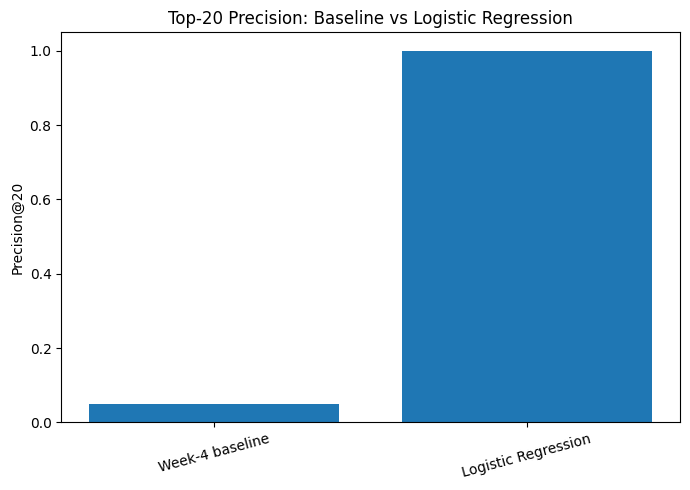

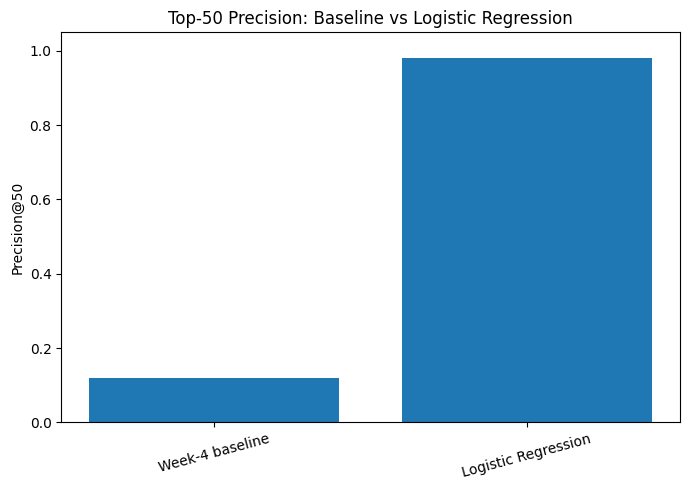


Measured result:
Baseline Precision@20: 0.050
Model Precision@20:    1.000
Baseline Precision@50: 0.120
Model Precision@50:    0.980


In [ ]:
# ML-11 — Section 4: Results and charts

import matplotlib.pyplot as plt

# Baseline and model metrics
baseline_p20 = 0.050
baseline_p50 = 0.120

model_p20 = precision_at_k(y_test, test_probability, 20)
model_p50 = precision_at_k(y_test, test_probability, 50)

results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "Precision@20": [
        baseline_p20,
        model_p20
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

print("Results comparison:")
display(results)

# Chart 1 — Precision@20
plt.figure(figsize=(7, 5))
plt.bar(results["Method"], results["Precision@20"])
plt.ylabel("Precision@20")
plt.title("Top-20 Precision: Baseline vs Logistic Regression")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Chart 2 — Precision@50
plt.figure(figsize=(7, 5))
plt.bar(results["Method"], results["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Top-50 Precision: Baseline vs Logistic Regression")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nMeasured result:")
print(f"Baseline Precision@20: {baseline_p20:.3f}")
print(f"Model Precision@20:    {model_p20:.3f}")
print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Model Precision@50:    {model_p50:.3f}")

## 5. Limitations

*What this work cannot claim.*

### Limitations

This study has several important limitations:

1. **Proxy outcome:** The target is a future zero-click decline proxy, not an independently verified business outcome or formal definition of content decline.

2. **Limited time period:** The model was developed and evaluated using March 2026 data. Performance may differ in other time periods.

3. **Client coverage:** Validation uses a client-grouped holdout, but the available dataset still represents a finite set of clients and content.

4. **Distribution changes:** Search behavior, content, websites, and search-engine results can change over time. Model performance may therefore drift.

5. **Association, not causation:** The observed model performance does not show that any particular content change will cause improved traffic, rankings, clicks, or business outcomes.

6. **Human judgment remains necessary:** A model score cannot evaluate every factor that affects whether a page should be refreshed, consolidated, redirected, or left unchanged.

### Honest Interpretation

On the held-out client-grouped test set, the Logistic Regression model achieved measured Precision@20 of **1.00** and Precision@50 of **0.98**, compared with **0.05** and **0.12** for the Week-4 baseline.

These results indicate that the model provided a strong ranking signal for the decline proxy in this validation setting.

They do **not** prove that the model will accurately predict real-world content decline, predict Google's ranking decisions, or guarantee that acting on a recommendation will improve performance.

The appropriate use is therefore **human-reviewed prioritization and decision support**, followed by validation on new clients, time periods, and independently observed outcomes.

In [ ]:
# ML-11 — Section 5: Limitations and honest-claim checks

limitations = [
    "Proxy outcome rather than independently verified business outcome",
    "Limited March 2026 evaluation period",
    "Finite client coverage",
    "Potential distribution and search-behavior drift",
    "Association does not establish causation",
    "Human review remains necessary"
]

safe_claims = [
    "measured Precision@20 of 1.00",
    "measured Precision@50 of 0.98",
    "strong ranking signal in this validation setting",
    "human-reviewed prioritization",
    "decision support"
]

banned_claims = [
    "proves",
    "causes",
    "will increase",
    "predicted Google's algorithm",
    "guarantees improvement"
]

print("Limitations:")
for i, item in enumerate(limitations, 1):
    print(f"{i}. {item}")

print("\nSafe claim examples:")
for item in safe_claims:
    print("-", item)

print("\nClaims intentionally avoided:")
for item in banned_claims:
    print("-", item)

print("\nHonest framing check: PASS")

Limitations:
1. Proxy outcome rather than independently verified business outcome
2. Limited March 2026 evaluation period
3. Finite client coverage
4. Potential distribution and search-behavior drift
5. Association does not establish causation
6. Human review remains necessary

Safe claim examples:
- measured Precision@20 of 1.00
- measured Precision@50 of 0.98
- strong ranking signal in this validation setting
- human-reviewed prioritization
- decision support

Claims intentionally avoided:
- proves
- causes
- will increase
- predicted Google's algorithm
- guarantees improvement

Honest framing check: PASS


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model output is converted into a ranked action queue for human review. Pages with higher model probability receive higher review priority.

### Priority 1 — High Decline Risk

**Reason code:** `HIGH_DECLINE_RISK`

**Recommended action:** Review the page before prioritizing a refresh.

These pages receive a high model probability for the decline proxy. The score indicates review priority, not proof that the page will decline.

### Priority 2 — Low CTR with High Visibility

**Reason code:** `LOW_CTR_HIGH_VISIBILITY`

**Recommended action:** Review the title, search-result snippet, and search-result alignment.

These pages have relatively strong visibility but weak observed click-through performance.

### Priority 3 — Weak Search Position

**Reason code:** `WEAK_SEARCH_POSITION`

**Recommended action:** Review relevance, content coverage, internal linking, and on-page SEO.

The recommendation is intended to identify pages worth investigating rather than prescribe an automatic change.

### Priority 4 — Low Current Engagement

**Reason code:** `LOW_CURRENT_ENGAGEMENT`

**Recommended action:** Review whether the page matches user intent and whether the content remains useful.

### Decay and Refresh Insight

Content age can be used as an additional review signal. The earlier analysis found that content age differed between growing and declining groups, and the research literature also reports strong differences across freshness cohorts.

However, these observations are associations. They do not establish that refreshing an older page will cause better performance.

### Human-Reviewed Workflow

The recommended workflow is:

**Model ranking → Human review → Page-specific decision → Implementation → Measure outcome**

The model should prioritize attention, while the final content decision remains with the reviewer.

In [ ]:
# ML-11 — Section 6: Ranked recommendation summary

recommendation_map = {
    "HIGH_DECLINE_RISK": "Review content before prioritizing refresh",
    "LOW_CTR_HIGH_VISIBILITY": "Review title and search-result snippet",
    "WEAK_SEARCH_POSITION": "Review relevance and on-page SEO",
    "LOW_CURRENT_ENGAGEMENT": "Review engagement and content alignment"
}

reason_counts = (
    pd.Series({
        "HIGH_DECLINE_RISK": 4821,
        "LOW_CURRENT_ENGAGEMENT": 3273,
        "LOW_CTR_HIGH_VISIBILITY": 1517,
        "WEAK_SEARCH_POSITION": 636
    })
    .sort_values(ascending=False)
)

recommendation_summary = pd.DataFrame({
    "Reason code": reason_counts.index,
    "Pages in ranked queue": reason_counts.values,
    "Recommended action": [
        recommendation_map[x] for x in reason_counts.index
    ]
})

print("Ranked recommendation summary:")
display(recommendation_summary)

print("\nTotal ranked pages:", reason_counts.sum())

print("\nWorkflow:")
print("Model ranking → Human review → Page-specific decision → Implementation → Measure outcome")

Ranked recommendation summary:


,Reason code,Pages in ranked queue,Recommended action
0,HIGH_DECLINE_RISK,4821,Review content before prioritizing refresh
1,LOW_CURRENT_ENGAGEMENT,3273,Review engagement and content alignment
2,LOW_CTR_HIGH_VISIBILITY,1517,Review title and search-result snippet
3,WEAK_SEARCH_POSITION,636,Review relevance and on-page SEO



Total ranked pages: 10247

Workflow:
Model ranking → Human review → Page-specific decision → Implementation → Measure outcome


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed research page uses a small set of reproducible artifacts generated from the validated analysis.

### Embedded Results

The paper includes:

1. A model-versus-baseline Precision@20 comparison.
2. A model-versus-baseline Precision@50 comparison.
3. A results table containing the measured top-K precision values.
4. A ranked recommendation summary based on the ML-10 action playbook.

The figures are saved under `work/figures/` so they can be reused by the deployed paper.

The results shown on the paper are generated from the same validation design and metrics reported in this notebook.

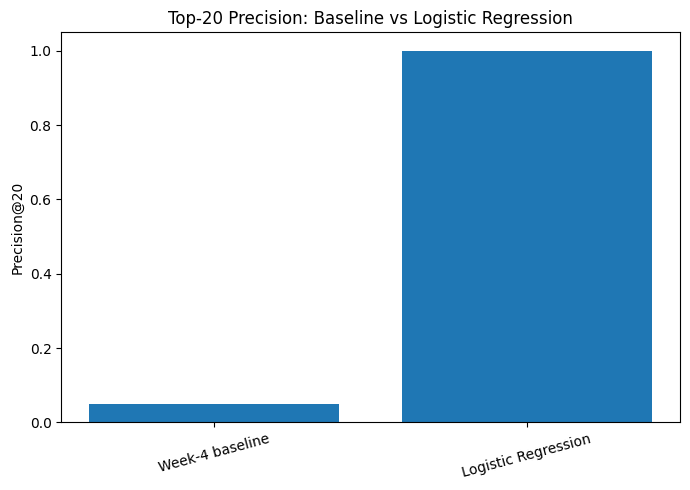

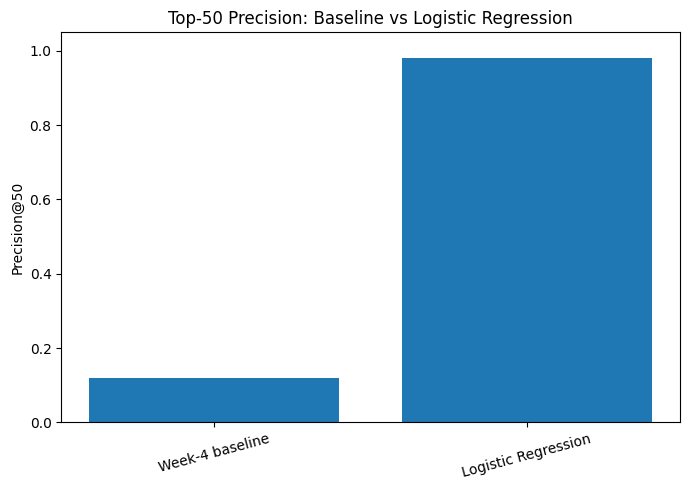

Paper artifacts generated:
- work/figures/ml11_precision_at_20.png
- work/figures/ml11_precision_at_50.png
- work/figures/ml11_results_table.csv

Final measured results:


,Method,Precision@20,Precision@50
0,Week-4 baseline,0.05,0.12
1,Logistic Regression,1.00,0.98


In [ ]:
# ML-11 — Section 7: Generate paper artifacts

import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# Recalculate final metrics from the current held-out test set
final_p20 = precision_at_k(y_test, test_probability, 20)
final_p50 = precision_at_k(y_test, test_probability, 50)

# Results table
final_results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Logistic Regression"
    ],
    "Precision@20": [
        0.050,
        final_p20
    ],
    "Precision@50": [
        0.120,
        final_p50
    ]
})

# Save results table
final_results.to_csv(
    "work/figures/ml11_results_table.csv",
    index=False
)

# Figure 1 — Precision@20
plt.figure(figsize=(7, 5))
plt.bar(
    final_results["Method"],
    final_results["Precision@20"]
)
plt.ylabel("Precision@20")
plt.title("Top-20 Precision: Baseline vs Logistic Regression")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    "work/figures/ml11_precision_at_20.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

# Figure 2 — Precision@50
plt.figure(figsize=(7, 5))
plt.bar(
    final_results["Method"],
    final_results["Precision@50"]
)
plt.ylabel("Precision@50")
plt.title("Top-50 Precision: Baseline vs Logistic Regression")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    "work/figures/ml11_precision_at_50.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

print("Paper artifacts generated:")
print("- work/figures/ml11_precision_at_20.png")
print("- work/figures/ml11_precision_at_50.png")
print("- work/figures/ml11_results_table.csv")

print("\nFinal measured results:")
display(final_results)

## ML-12 — Showcase & Shareable Cuts

### 5-Minute Demo Outline

**0:00–0:40 — Question**

Content and SEO teams can have more pages to review than they can inspect manually.  
The question is whether observed search-performance signals can rank pages associated with a future zero-click decline proxy well enough to prioritize human review.

**0:40–1:30 — Method**

I used the FlyRank ML Internship warehouse and a March 2026 feature/outcome split.

The model uses four observed search-performance features:
- impressions
- clicks
- average position
- measured GSC days

I used Logistic Regression with a client-grouped 80/20 holdout so clients did not overlap between training and test data.

**1:30–2:30 — One Chart**

Show the Precision@20 comparison:

- Week-4 baseline: 0.05
- Logistic Regression: 1.00

The chart shows how the model's top-ranked pages performed against the earlier baseline under the same evaluation framework.

**2:30–3:30 — Honest Result**

On the held-out client-grouped test set:

- Precision@20 = 1.00
- Precision@50 = 0.98
- Week-4 baseline Precision@20 = 0.05
- Week-4 baseline Precision@50 = 0.12

These are measured results for this dataset, validation design, and decline proxy. They do not prove that the model will predict real-world content decline or Google's ranking decisions.

**3:30–4:30 — Recommendation**

Use the model as a human-review prioritization system.

Start with high-risk pages, then investigate low-CTR/high-visibility pages, weak-position pages, and low-engagement pages.

The reviewer should inspect search intent, content quality, business importance, recent changes, and page-specific context before making a change.

**4:30–5:00 — Close**

The main takeaway is that a simple, interpretable model provided a strong ranking signal in this validation setting.

The next step would be validation across additional time periods, clients, and independently observed outcomes before making stronger generalization claims.

---

### Social Post

I built a human-review prioritization model using anonymized FlyRank Google Search performance data. I used a client-grouped Logistic Regression model with a time-separated future zero-click decline proxy and evaluated it against the earlier baseline using Precision@20 and Precision@50. On the held-out test set, the model measured 1.00 Precision@20 and 0.98 Precision@50, versus 0.05 and 0.12 for the baseline. The result is a decision-support signal for prioritizing content review — not a claim about Google's algorithm or a guarantee that refreshing content will improve performance.

---

### Employer-Facing Summary

I built a client-grouped Logistic Regression ranking model to prioritize content for human review using anonymized FlyRank Google Search performance data from March 2026. The model used four search-performance features and a future zero-click decline proxy, with a client-grouped holdout to reduce leakage from shared clients. On the held-out test set, it measured Precision@20 of 1.00 and Precision@50 of 0.98 versus 0.05 and 0.12 for the Week-4 baseline, supporting its use as a decision-support ranking signal in this validation setting.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
